In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def display(img, cmap="grap"):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")

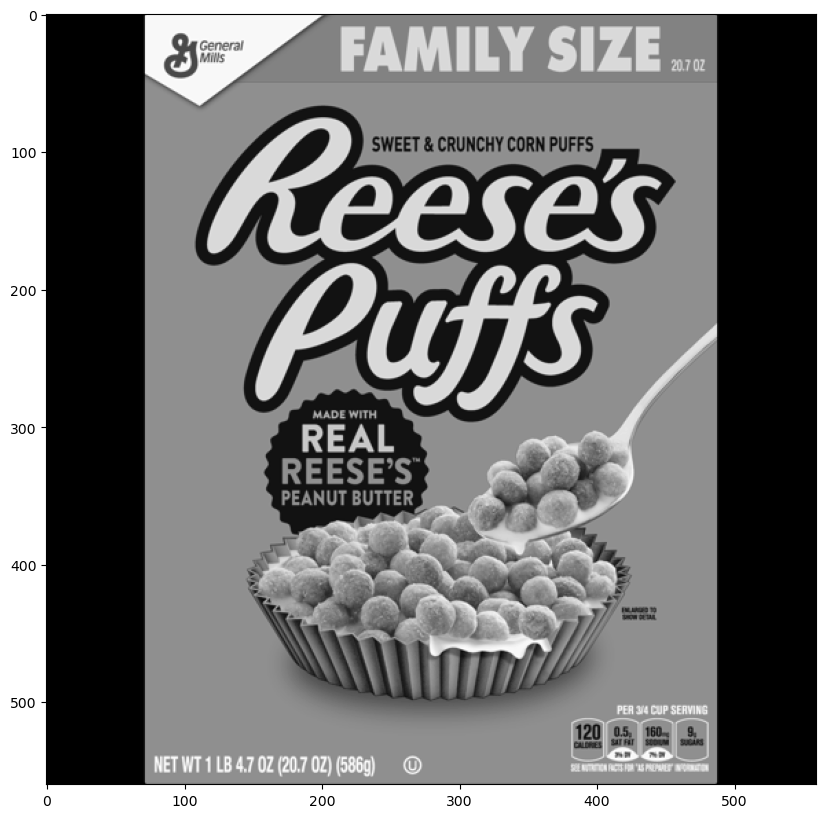

In [3]:
reeses = cv2.imread("data/reeses_puffs.png", 0)
display(reeses)

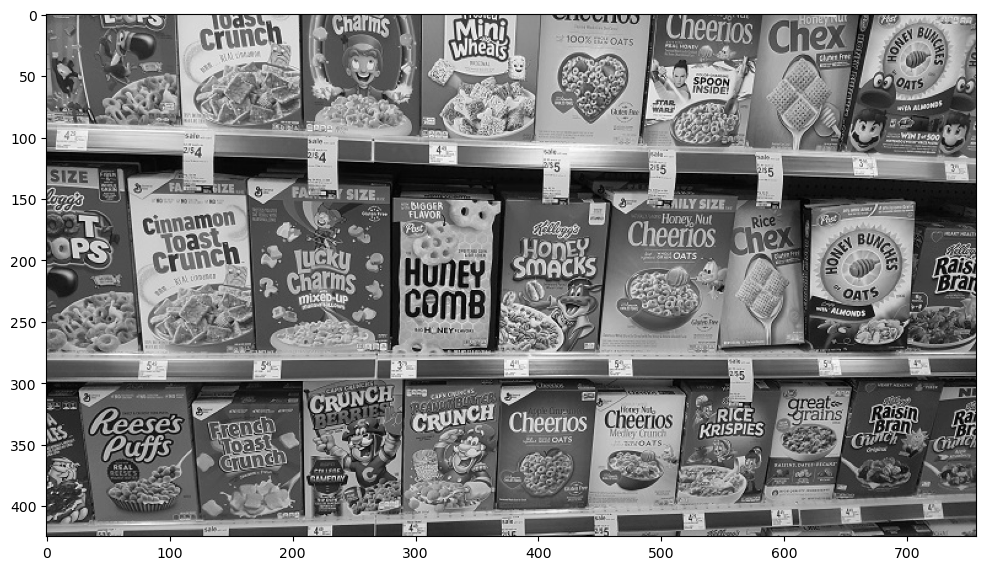

In [4]:
# Target image
cereals = cv2.imread("data/many_cereals.jpg", 0)
display(cereals)

In [6]:
# Method 1

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(reeses, None)
# Returns key points and descriptor
kp2, des2 = orb.detectAndCompute(cereals, None)

# Brute force matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key = lambda x:x.distance)

print(len(matches))

138


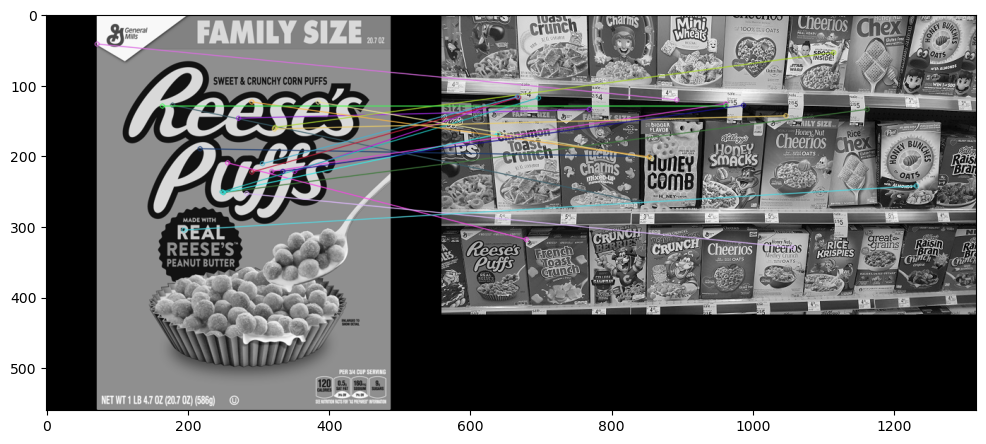

In [11]:
# Lets pick the top 20 matches
reeses_matches = cv2.drawMatches(reeses, kp1, cereals, kp2, matches[:20], None, flags=2)

display(reeses_matches)

In [15]:
#2 Method 2 - SIFT = Scale Invariant Feature Transform

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)
# k=2 means find the top 2 matches

In [20]:
matches
# Note that each touple has 2 matches.
# 1st match is better than the 2nd - they're sorted.
# If 1st is close to 2nd in distance, then its a good feature to match.
# If the 2 points are not close in distance, they're not a good feature to match
# Less distance = better match

((< cv2.DMatch 0x12d2a7970>, < cv2.DMatch 0x12eb50bd0>),
 (< cv2.DMatch 0x12eb51110>, < cv2.DMatch 0x12eb50cb0>),
 (< cv2.DMatch 0x12eb51090>, < cv2.DMatch 0x12eb510d0>),
 (< cv2.DMatch 0x12eb50f10>, < cv2.DMatch 0x12eb516f0>),
 (< cv2.DMatch 0x12eb50bf0>, < cv2.DMatch 0x12eb510b0>),
 (< cv2.DMatch 0x12eb510f0>, < cv2.DMatch 0x12eb51050>),
 (< cv2.DMatch 0x12eb51070>, < cv2.DMatch 0x12eb51170>),
 (< cv2.DMatch 0x12eb50bb0>, < cv2.DMatch 0x12eb50b30>),
 (< cv2.DMatch 0x12eb511f0>, < cv2.DMatch 0x12eb51310>),
 (< cv2.DMatch 0x12eb512f0>, < cv2.DMatch 0x12eb51290>),
 (< cv2.DMatch 0x12eb512b0>, < cv2.DMatch 0x12eb51270>),
 (< cv2.DMatch 0x12eb513d0>, < cv2.DMatch 0x12eb514f0>),
 (< cv2.DMatch 0x12eb514d0>, < cv2.DMatch 0x12eb514b0>),
 (< cv2.DMatch 0x12eb51490>, < cv2.DMatch 0x12eb51470>),
 (< cv2.DMatch 0x12eb50fb0>, < cv2.DMatch 0x12eb51570>),
 (< cv2.DMatch 0x12eb51590>, < cv2.DMatch 0x12eb515b0>),
 (< cv2.DMatch 0x12eb515d0>, < cv2.DMatch 0x12eb515f0>),
 (< cv2.DMatch 0x12eb51610>, < 

79
1501


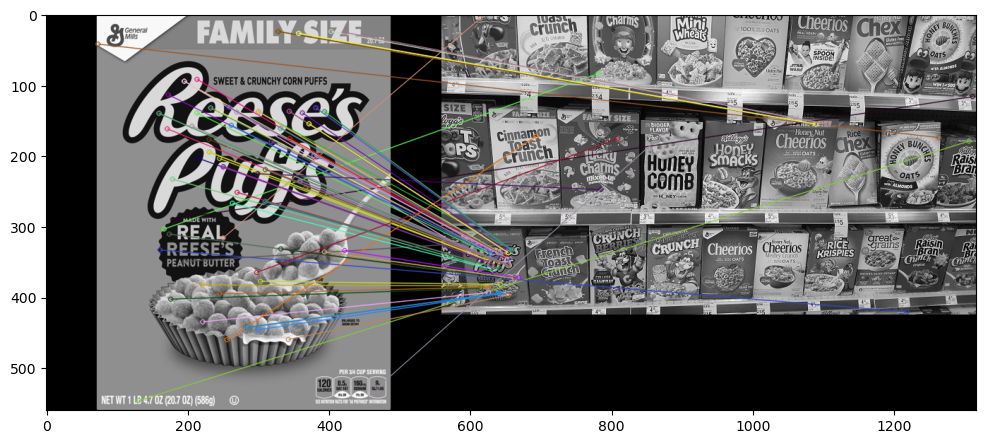

In [21]:
# Ratio matching
good_matches = []

for match1, match2 in matches:
    # If match1 distance is < 75% of match2 distance, then it was a good match
    if match1.distance < 0.75*match2.distance:
        good_matches.append([match1])

print(len(good_matches))
print(len(matches))
# We've removed several bad matches

sift_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good_matches, None, flags=2)
display(sift_matches)

79
1501


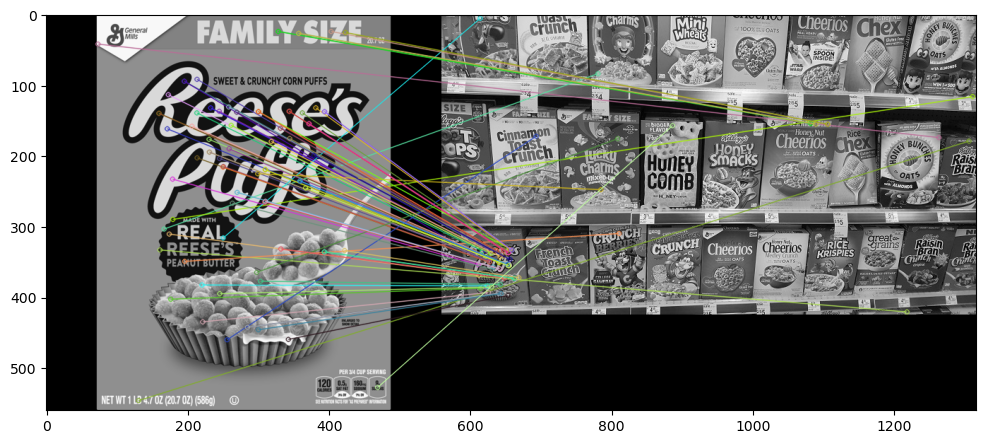

In [24]:
# Method 3

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

# Instead of brute force, using flann
# FLANN = Fast Library for Approximate Nearest neighbours

# Default parameters
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

good_matches = []

for match1, match2 in matches:
    # If match1 distance is < 75% of match2 distance, then it was a good match
    if match1.distance < 0.75*match2.distance:
        good_matches.append([match1])

print(len(good_matches))
print(len(matches))

flann_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good_matches, None, flags=2)
display(flann_matches)

1501
1501


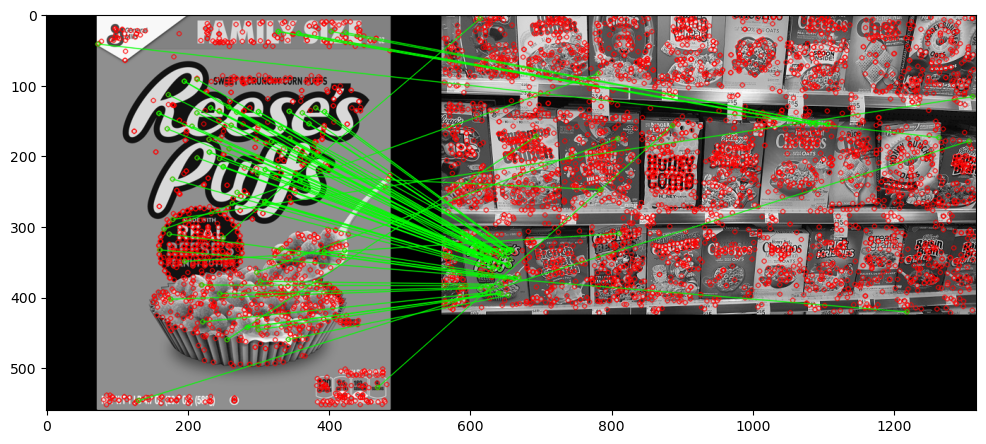

In [30]:
# Method 3 with masking

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

# Instead of brute force, using flann
# FLANN = Fast Library for Approximate Nearest neighbours

# Default parameters
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

matches_mask = [[0, 0] for i in range(len(matches))]

for i, (match1, match2) in enumerate(matches):
    # If match1 distance is < 75% of match2 distance, then it was a good match
    if match1.distance < 0.75*match2.distance:
        matches_mask[i] = [1, 0]

print(len(matches_mask))
print(len(matches))

draw_params = dict(matchColor=(0, 255, 0),
                   singlePointColor=(255, 0, 0),
                   matchesMask=matches_mask,
                   flags=0)

flann_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, matches, None, **draw_params)
display(flann_matches)